In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import metrics

In [14]:
df_train = pd.read_csv('../../data/train_pca.csv')
df_test = pd.read_csv('../../data/test_pca.csv')
x_train = df_train.drop(columns=['target'])
y_train = df_train['target']
x_test = df_test.drop(columns=['target'])
y_test = df_test['target']

In [15]:
inertia = []
k_range = range(1, 11)  # Checking K from 1 to 10

# 2. Loop through each K
for k in k_range:
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    kmeans.fit(x_train)
    inertia.append(kmeans.inertia_)

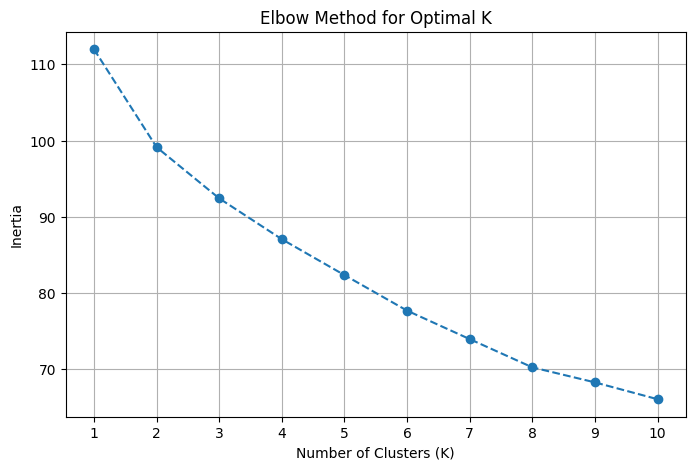

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [17]:
scores = []
k_range = range(2, 11) # Silhouette needs at least 2 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(x_train)
    score = silhouette_score(x_train, kmeans.labels_)
    scores.append(score)
    print(f"For n_clusters = {k}, silhouette score is {score:.4f}")

For n_clusters = 10, silhouette score is 0.1384


In [18]:
best_k = 8
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)

# 2. Assign cluster labels to your training and test sets
df_train['cluster_label'] = kmeans.fit_predict(x_train)
df_test['cluster_label'] = kmeans.predict(x_test)

# 3. Quick check: how many samples fell into each cluster?
print(df_train['cluster_label'].value_counts())

cluster_label
1    47
3    33
0    31
4    29
2    28
7    27
6    23
5    19
Name: count, dtype: int64


In [19]:
ari = metrics.adjusted_rand_score(y_train, df_train['cluster_label'])
homogeneity = metrics.homogeneity_score(y_train, df_train['cluster_label'])
completeness = metrics.completeness_score(y_train, df_train['cluster_label'])

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Homogeneity: {homogeneity:.4f}")
print(f"Completeness: {completeness:.4f}")

Adjusted Rand Index: 0.1116
Homogeneity: 0.3386
Completeness: 0.1145
